In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

In [2]:
import importlib
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import monk_common as mc
import knn_common as kc
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


In [3]:
importlib.reload(mc)
importlib.reload(kc)

<module 'knn_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/collaudo/knn_common.py'>

In [4]:
# Split for KFold
n_split = 5
default_cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)

default_krange = list(range(1, 41, 2))


<h2>Exploring Dataset</h2>
<hr/>

<h3>Monk 1</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [5]:
monk_1_TR_orig, monk_1_TS_orig = mc.load_set(1)
monk_1_TR_features, monk_1_TR_labels = mc.split_and_prepare_dataset(monk_1_TR_orig)
monk_1_TS_features, monk_1_TS_labels = mc.split_and_prepare_dataset(monk_1_TS_orig)
mc.dataset_introspection(monk_1_TR_orig, monk_1_TS_orig)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


In [24]:
model_1, cv_scores_1, train_scores_1 = kc.find_best_knn_model(
    monk_1_TR_features, monk_1_TR_labels, default_cv, default_krange
)

best_k, best_mean, best_std = kc.knn_introspection(cv_scores_1)


Best k: 5
Best mean accuracy: 0.782
Std: 0.042142615011410964


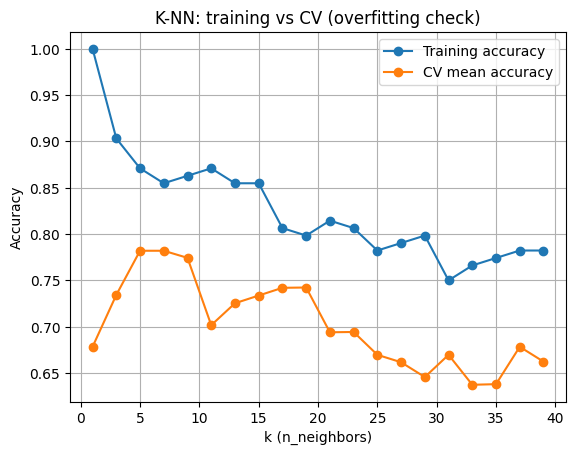

In [7]:
kc.plot_knn_validation_curve(cv_scores_1, train_scores_1)

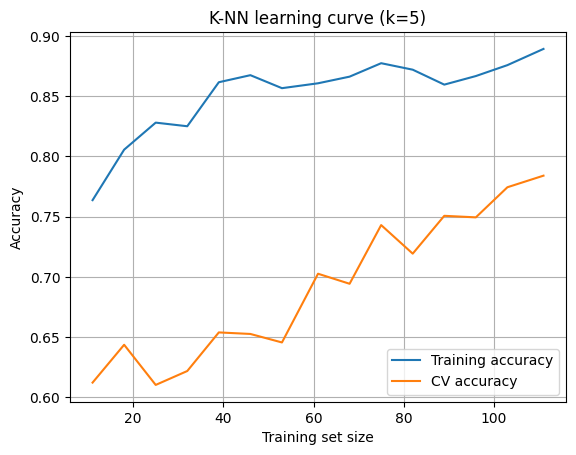

In [26]:
kc.plot_knn_learning_curve(monk_1_TR_features, monk_1_TR_labels, best_k, 5 , 42)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [9]:
model_1.fit(monk_1_TR_features, monk_1_TR_labels)
monk_1_TS_labels_pred = model_1.predict(monk_1_TS_features)

In [10]:
print(classification_report(monk_1_TS_labels, monk_1_TS_labels_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       216
           1       0.84      0.76      0.80       216

    accuracy                           0.81       432
   macro avg       0.81      0.81      0.81       432
weighted avg       0.81      0.81      0.81       432



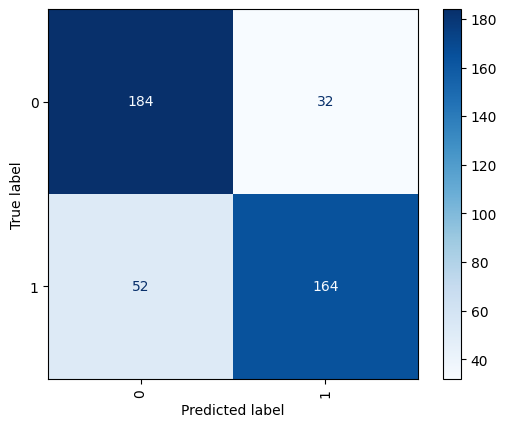

In [11]:
ConfusionMatrixDisplay.from_predictions(monk_1_TS_labels, monk_1_TS_labels_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 2</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [12]:
monk_2_TR_orig, monk_2_TS_orig = mc.load_set(2)
monk_2_TR_features, monk_2_TR_labels = mc.split_and_prepare_dataset(monk_2_TR_orig)
monk_2_TS_features, monk_2_TS_labels = mc.split_and_prepare_dataset(monk_2_TS_orig)
mc.dataset_introspection(monk_2_TR_orig, monk_2_TS_orig)

,Property,Training,Test
0,Number of samples,169,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 105, class 1 = 64","class 0 = 290, class 1 = 142"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

In [13]:
model_2, cv_scores_2, train_scores_2 = kc.find_best_knn_model(
    monk_2_TR_features, monk_2_TR_labels, default_cv, default_krange
)

kc.knn_introspection(cv_scores_2)

Best k: 21
Best mean accuracy: 0.6926916221033869
Std: 0.058946018421255256


(21, np.float64(0.6926916221033869), np.float64(0.058946018421255256))

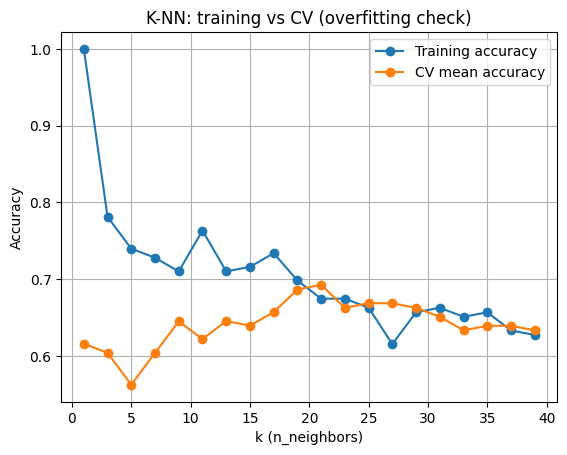

In [14]:
kc.plot_knn_validation_curve(cv_scores_2, train_scores_2)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [15]:
model_2.fit(monk_2_TR_features, monk_2_TR_labels)
monk_2_TS_labels_pred = model_2.predict(monk_2_TS_features)

In [16]:
print(classification_report(monk_2_TS_labels, monk_2_TS_labels_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.69      0.87      0.77       290
           1       0.43      0.21      0.28       142

    accuracy                           0.65       432
   macro avg       0.56      0.54      0.53       432
weighted avg       0.61      0.65      0.61       432



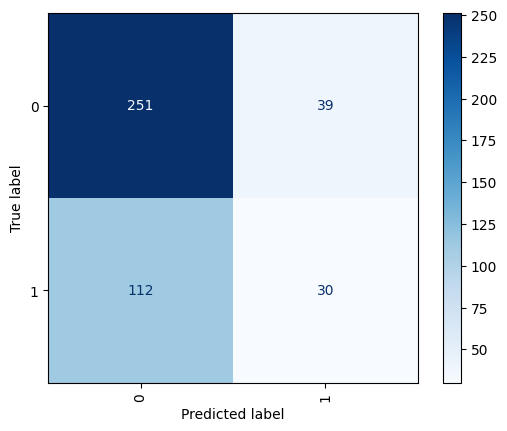

In [17]:
ConfusionMatrixDisplay.from_predictions(monk_2_TS_labels, monk_2_TS_labels_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 3</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [18]:
monk_3_TR_orig, monk_3_TS_orig = mc.load_set(3)
monk_3_TR_features, monk_3_TR_labels = mc.split_and_prepare_dataset(monk_3_TR_orig)
monk_3_TS_features, monk_3_TS_labels = mc.split_and_prepare_dataset(monk_3_TS_orig)
mc.dataset_introspection(monk_3_TR_orig, monk_3_TS_orig)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

In [19]:
model_3, cv_scores_3, train_scores_3 = kc.find_best_knn_model(
    monk_3_TR_features, monk_3_TR_labels, default_cv, default_krange
)

kc.knn_introspection(cv_scores_3)

Best k: 21
Best mean accuracy: 0.8856666666666667
Std: 0.04711215931747934


(21, np.float64(0.8856666666666667), np.float64(0.04711215931747934))

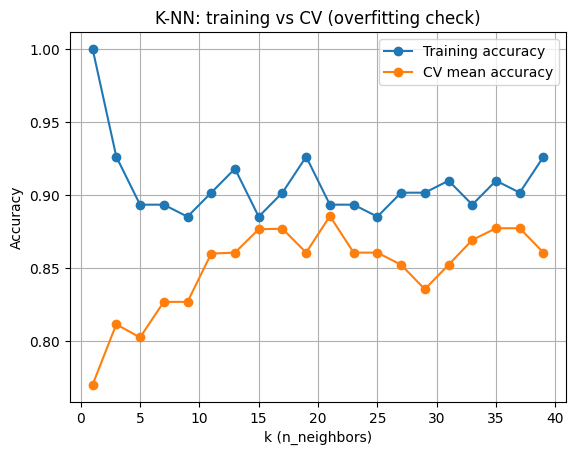

In [20]:
kc.plot_knn_validation_curve(cv_scores_3, train_scores_3)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [21]:
model_3.fit(monk_3_TR_features, monk_3_TR_labels)
monk_3_TS_labels_pred = model_3.predict(monk_3_TS_features)

In [22]:
print(classification_report(monk_3_TS_labels, monk_3_TS_labels_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       204
           1       0.95      0.88      0.91       228

    accuracy                           0.91       432
   macro avg       0.91      0.91      0.91       432
weighted avg       0.91      0.91      0.91       432



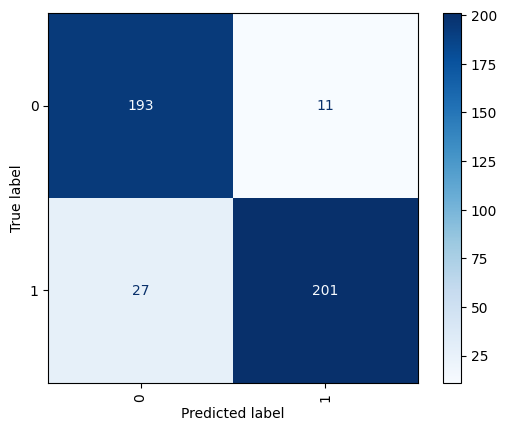

In [23]:
ConfusionMatrixDisplay.from_predictions(monk_3_TS_labels, monk_3_TS_labels_pred, xticks_rotation='vertical', cmap='Blues');